# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Смачило Іванна Ростиславівна'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-33'      # напр. 'КН-31'
ВАРІАНТ = 11     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Смачило Іванна Ростиславівна, ШІ-33, варіант 11
ваш потік:                   P>10
ваша пара для графіка 3:     радіопотік F10.7 та потік P>10
ваш агрегат для етапу 4:     середнє
ваше додаткове питання:      Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
# ВАШ КОД
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_excel("20171129_FINAL_FINAL.xlsx")
df.head()
df.columns
df.dtypes

Unnamed: 0                                     float64
ftp://ftp.swpc.noaa.gov/pub/lists/particle/     object
Unnamed: 2                                      object
Unnamed: 3                                      object
Unnamed: 4                                      object
Unnamed: 5                                      object
Unnamed: 6                                      object
Unnamed: 7                                      object
Unnamed: 8                                      object
Unnamed: 9                                      object
Unnamed: 10                                     object
Unnamed: 11                                     object
Unnamed: 12                                     object
Unnamed: 13                                     object
Unnamed: 14                                     object
Unnamed: 15                                    float64
Unnamed: 16                                     object
Unnamed: 17                                     object
Unnamed: 1

**Відповідь 1.1:** Звичайне читання дало саме такий результат, бо файл це як одна чиста таблиця. У першому рядку аркуша знаходиться не заголовок стовпців, а текстовий опис або посилання на джерело даних, тому pandas помилково бере цей рядок за назви стовпців. Також в одному аркуші розміщено три різні таблиці, які розділені порожніми стовпцями, а pandas не розпізнає такий розподіл і підписує порожні стовпці як безіменні. Саме через це частина стовпців отримала тип object замість float64/int64. Там змішані текстові підписи й числові дані.

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [5]:
# ВАШ КОД
RAW = pd.read_excel("20171129_FINAL_FINAL.xlsx", header=None)
print(RAW.shape)
RAW.head(30)


(7226, 32)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [6]:
# ВАШ КОД
RAW.notna().sum()

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64

**Відповідь 1.3:** В аркуші три таблиці, розділені порожніми стовпцями. Таблиця А займає стовпці 1-14(Excel B:O), таблиця В – стовпці 16-19(Excel Q:T), таблиця С – стовпці 24-31(Excel Y:AF, Y і Z – допоміжний індекс рядка). 

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [7]:
# ВАШ КОД
print("Таблиця A:")
print(RAW.loc[:24, 1].dropna().to_string(index=False))

print("Таблиця B:")
print(RAW.loc[:25, 16].dropna().to_string(index=False))

print("Таблиця C:")
print(RAW.loc[:25, 26].dropna().to_string(index=False))

Таблиця A:
       ftp://ftp.swpc.noaa.gov/pub/lists/particle/
               :Data_list: 20170901_Gs_part_5m.txt
                    :Created: 2017 Sep 02 0011 UTC
# Prepared by the U.S. Dept. of Commerce, NOAA,...
# Please send comments and suggestions to SWPC....
                                                # 
              # Label: P > 1 = Particles at >1 Mev
              # Label: P > 5 = Particles at >5 Mev
             # Label: P >10 = Particles at >10 Mev
             # Label: P >30 = Particles at >30 Mev
             # Label: P >50 = Particles at >50 Mev
            # Label: P>100 = Particles at >100 Mev
            # Label: E>0.8 = Electrons at >0.8 Mev
            # Label: E>2.0 = Electrons at >2.0 Mev
            # Label: E>4.0 = Electrons at >4.0 Mev
             # Units: Particles = Protons/cm2-s-sr
           # Units: Electrons = Electrons/cm2-s-sr
                                 # Source: GOES-15
                                  # Location: W135
                    

**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | GOES-15 (ftp://ftp.swpc.noaa.gov/pub/lists/particle/) | Particles = Protons/cm2-s-sr
Electrons = Electrons/cm2-s-sr |
| B | Daily Solar Data (ftp://ftp.swpc.noaa.gov/pub/indices/old_indices/2017Q3_DSD.txt) | sfu |
| C | SOHO CELIAS Proton Monitor (http://umtof.umd.edu/pm/crn/) | Proton speed [km/sec]
Proton density [protons per cubic centimeter] |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [8]:
# ВАШ КОД
A = pd.read_excel(
    "20171129_FINAL_FINAL.xlsx",
    sheet_name="Sheet1",
    usecols="B:O",
    skiprows=25,
    header=0,
)
A.columns = ["YR", "MO", "DA", "HHMM", "Julian_Day", "Seconds", "P > 1", "P > 5", "P >10", "P >30", "P >50", "P>100", "E>0.8", "E>2.0"]
A = A.apply(pd.to_numeric, errors="coerce")
A = A.dropna(how="all")
A = A.reset_index(drop=True) 
print(len(A))
A.head()

B = pd.read_excel(
    "20171129_FINAL_FINAL.xlsx",
    sheet_name="Sheet1",
    usecols="Q:T",
    skiprows=26,
    header=0,
)
B.columns = ["YR", "MO", "DA", "F10_7"]
B = B.apply(pd.to_numeric, errors="coerce")
B = B.dropna(how="all")
B = B.reset_index(drop=True) 
print(len(B))
B.head()

C = pd.read_excel(
    "20171129_FINAL_FINAL.xlsx",
    sheet_name="Sheet1",
    usecols="AA:AF",
    skiprows=26,
    header=0,
)
C.columns = ["YR", "MO", "DA", "HH", "SPEED", "DENSITY"]
C = C.apply(pd.to_numeric, errors="coerce")
C = C.dropna(how="all")
C = C.reset_index(drop=True) 
print(len(C))
C.head()


7200
25
601


,YR,MO,DA,HH,SPEED,DENSITY
0,17.0,8.0,28.0,0.0,285.0,3.0
1,17.0,8.0,28.0,1.0,305.0,3.4
2,17.0,8.0,28.0,2.0,309.0,1.7
3,17.0,8.0,28.0,3.0,304.0,2.0
4,17.0,8.0,28.0,4.0,302.0,2.3


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [9]:
# ВАШ КОД
hour = A["HHMM"] // 100
minute = A["HHMM"] % 100

A["ts"] = pd.to_datetime(
    dict(year=A["YR"], month=A["MO"], day=A["DA"], hour=hour, minute=minute)
)
print(A["ts"].min(), A["ts"].max())

B["ts"] = pd.to_datetime(dict(year=B["YR"], month=B["MO"], day=B["DA"]))
print(B["ts"].min(), B["ts"].max())

C["ts"] = pd.to_datetime(
    dict(year=C["YR"] + 2000, month=C["MO"], day=C["DA"], hour=C["HH"])
)
print(C["ts"].min(), C["ts"].max())

2017-08-28 00:00:00 2017-09-21 23:55:00
2017-08-28 00:00:00 2017-09-21 00:00:00
2017-08-28 00:00:00 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [10]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [11]:
# ВАШ КОД
print("Таблиця A:")
print("Розмір:", A.shape)
print("\nТипи стовпців:\n", A.dtypes)
print("\nПропусків:")
print(A.isna().sum().to_string())
print("\nДублікатів рядків:", A.duplicated().sum())
A.describe()

print("Таблиця B:")
print("Розмір:", B.shape)
print("\nТипи стовпців:\n", B.dtypes)
print("\nПропусків:")
print(B.isna().sum().to_string())
print("\nДублікатів рядків:", B.duplicated().sum())
B.describe()

print("Таблиця C:")
print("Розмір:", C.shape)
print("\nТипи стовпців:\n", C.dtypes)
print("\nПропусків:")
print(C.isna().sum().to_string())
print("\nДублікатів рядків:", C.duplicated().sum())
C.describe()

Таблиця A:
Розмір: (7200, 15)

Типи стовпців:
 YR                     int64
MO                     int64
DA                     int64
HHMM                   int64
Julian_Day             int64
Seconds                int64
P > 1                float64
P > 5                float64
P >10                float64
P >30                float64
P >50                float64
P>100                float64
E>0.8                float64
E>2.0                float64
ts            datetime64[ns]
dtype: object

Пропусків:
YR            0
MO            0
DA            0
HHMM          0
Julian_Day    0
Seconds       0
P > 1         3
P > 5         3
P >10         3
P >30         3
P >50         3
P>100         3
E>0.8         3
E>2.0         3
ts            0

Дублікатів рядків: 0
Таблиця B:
Розмір: (25, 5)

Типи стовпців:
 YR              float64
MO              float64
DA              float64
F10_7           float64
ts       datetime64[ns]
dtype: object

Пропусків:
YR       0
MO       0
DA       0
F10_7  

,YR,MO,DA,HH,SPEED,DENSITY,ts
count,601.0,601.000000,601.000000,601.000000,601.000000,601.000000,601
mean,17.0,8.840266,13.973378,11.480865,506.547421,2.907654,2017-09-09 12:00:00
min,17.0,8.000000,1.000000,0.000000,-1.000000,-1.000000,2017-08-28 00:00:00
25%,17.0,9.000000,7.000000,5.000000,447.000000,1.800000,2017-09-03 06:00:00
50%,17.0,9.000000,13.000000,11.000000,517.000000,2.400000,2017-09-09 12:00:00
75%,17.0,9.000000,19.000000,17.000000,584.000000,3.400000,2017-09-15 18:00:00
max,17.0,9.000000,31.000000,23.000000,806.000000,31.700000,2017-09-22 00:00:00
std,0.0,0.366664,8.781000,6.938063,125.073291,2.637873,NaN


### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [12]:
# ВАШ КОД
import numpy as np

speed_mean_before = C["SPEED"].mean()
speed_min_before  = C["SPEED"].min()
density_mean_before = C["DENSITY"].mean()
density_min_before  = C["DENSITY"].min()

print("SPEED == -1:", (C["SPEED"] == -1).sum())
print("DENSITY == -1:", (C["DENSITY"] == -1).sum())

C.loc[C["SPEED"] < 0, "SPEED"] = np.nan
C.loc[C["DENSITY"] < 0, "DENSITY"] = np.nan

print("\nSPEED:   до mean =", speed_mean_before, " min =", speed_min_before)
print("SPEED:   після mean =", C["SPEED"].mean(), " min =", C["SPEED"].min())
print("\nDENSITY: до mean =", density_mean_before, " min =", density_min_before)
print("DENSITY: після mean =", C["DENSITY"].mean(), " min =", C["DENSITY"].min())

SPEED == -1: 8
DENSITY == -1: 8

SPEED:   до mean = 506.5474209650582  min = -1.0
SPEED:   після mean = 513.3946037099494  min = 277.0

DENSITY: до mean = 2.9076539101497505  min = -1.0
DENSITY: після mean = 2.960370994940978  min = 0.1


**Відповідь 3.2:** У таблиці C стовпці SPEED і DENSITY містять по 8 відʼємних значень, а саме -1. Оскільки швидкість і густина – фізичні величини, які не можуть бути відʼємними, ці значення не є реальними вимірюваннями, а є кодом, що дані відсутні. Мінімум після очищення став фізично осмисленим, а середнє трохи зросло, бо штучно занижені значення більше не впливають на розрахунок.

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [13]:
# ВАШ КОД
A[["YR", "MO", "DA", "Julian_Day", "HHMM", "Seconds"]].describe()

,YR,MO,DA,Julian_Day,HHMM,Seconds
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000
mean,2017.0,8.840000,13.960000,58005.000000,1177.500000,43050.000000
std,0.0,0.366632,8.775483,7.211603,692.481902,24943.113498
min,2017.0,8.000000,1.000000,57993.000000,0.000000,0.000000
25%,2017.0,9.000000,7.000000,57999.000000,588.750000,21525.000000
50%,2017.0,9.000000,13.000000,58005.000000,1177.500000,43050.000000
75%,2017.0,9.000000,19.000000,58011.000000,1766.250000,64575.000000
max,2017.0,9.000000,31.000000,58017.000000,2355.000000,86100.000000


**Відповідь 3.3:** Стовпці YR, MO, DA, Julian_Day, HHMM, Seconds – не є результатами вимірювання, а тільки позначення моменту часу, коли було зроблено запис. Рахувати для них середнє арифметичне нема сенсу, бо результати не описують жодного реального явища. На відміну від них, стовпці P>1,…,E>2.0 – реальні фізичні вимірювання і для них середнє арифметичне має змістовний сенс, бо воно показує типовий рівень потоку за період спостереження.

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [14]:
# ВАШ КОД
flow_cols = ["P > 1", "P > 5", "P >10", "P >30", "P >50", "P>100", "E>0.8", "E>2.0"]

A_hourly = (
    A.set_index("ts")[flow_cols]
    .resample("h")
    .agg(["mean", "max"])
)
A_hourly.columns = ["_".join(col).strip() for col in A_hourly.columns]
A_hourly = A_hourly.reset_index()

print(A_hourly.shape)
A_hourly.head()

(600, 17)


,ts,P > 1_mean,P > 1_max,P > 5_mean,P > 5_max,P >10_mean,P >10_max,P >30_mean,P >30_max,P >50_mean,P >50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

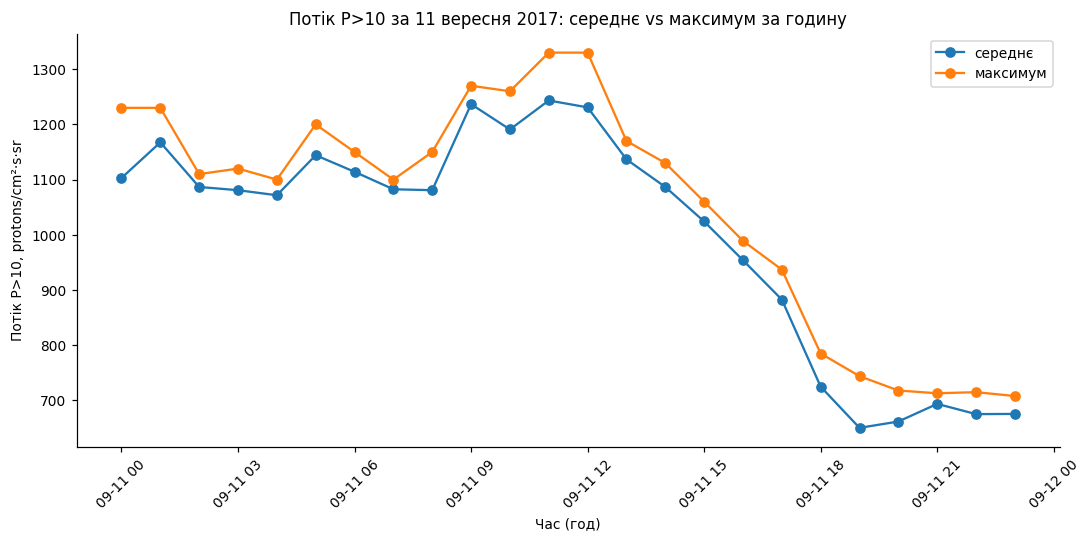

In [15]:
# ВАШ КОД
import matplotlib.pyplot as plt

день = A_hourly[A_hourly["ts"].dt.date == pd.Timestamp("2017-09-11").date()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(день["ts"], день["P >10_mean"], marker="o", label="середнє")
ax.plot(день["ts"], день["P >10_max"], marker="o", label="максимум")

ax.set_xlabel("Час (год)")
ax.set_ylabel("Потік P>10, protons/cm²·s·sr")
ax.set_title("Потік P>10 за 11 вересня 2017: середнє vs максимум за годину")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Відповідь 4.2:** Середнє і максимум відрізняються тим, що середнє показує типовий рівень за годину, а максимум показує найвищий одиничний спалах у цій годині. Коли сам потік протягом години поводиться відносно рівно, різниця між ними мала. Але коли всередині години стається різкий, короткий стрибок, максимум це вловлює, а середнє – згладжує і різниця між двома кривими зростає. Тому якщо цікавить саме пікове, найнебезпечніше значення, треба дивитись на максимум, а не на середнє.

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [16]:
# ВАШ КОД
M_inner = A_hourly.merge(C[["ts", "SPEED", "DENSITY"]], on="ts", how="inner")
M_outer = A_hourly.merge(C[["ts", "SPEED", "DENSITY"]], on="ts", how="outer")

print("inner:", M_inner.shape)
print("outer:", M_outer.shape)

M_inner["date"] = M_inner["ts"].dt.date
B_daily = B[["ts", "F10_7"]].copy()
B_daily["date"] = B_daily["ts"].dt.date

M = M_inner.merge(B_daily[["date", "F10_7"]], on="date", how="left")
M = M.drop(columns="date")

print(M.shape)
M[M.isna().any(axis=1)]


inner: (600, 19)
outer: (601, 19)
(600, 20)


,ts,P > 1_mean,P > 1_max,P > 5_mean,P > 5_max,P >10_mean,P >10_max,P >30_mean,P >30_max,P >50_mean,P >50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max,SPEED,DENSITY,F10_7
175,2017-09-04 07:00:00,6.465833,10.10,0.262083,0.593,0.171500,0.294,0.085483,0.145,0.068558,0.134,0.031717,0.0523,90600.000000,100000.0,7410.833333,8950.0,NaN,NaN,140.0
176,2017-09-04 08:00:00,4.010833,5.08,0.256000,0.432,0.195833,0.336,0.086625,0.145,0.070033,0.134,0.036492,0.0546,73483.333333,79300.0,5048.333333,5850.0,NaN,NaN,140.0
177,2017-09-04 09:00:00,3.268333,4.42,0.303417,0.518,0.220333,0.302,0.105925,0.162,0.081975,0.134,0.046483,0.0765,60475.000000,68500.0,3715.833333,4480.0,NaN,NaN,140.0
178,2017-09-04 10:00:00,3.179167,4.74,0.252167,0.372,0.181833,0.280,0.101900,0.150,0.081675,0.120,0.054125,0.0894,64383.333333,68400.0,4122.500000,4710.0,NaN,NaN,140.0
179,2017-09-04 11:00:00,5.274167,7.98,0.295083,0.657,0.186917,0.276,0.089525,0.166,0.063983,0.110,0.033633,0.0684,79933.333333,88200.0,6345.833333,7430.0,NaN,NaN,140.0
180,2017-09-04 12:00:00,2.965000,4.85,0.217750,0.428,0.153500,0.239,0.089217,0.179,0.071217,0.144,0.037233,0.0679,80516.666667,88700.0,6080.000000,7420.0,NaN,NaN,140.0
181,2017-09-04 13:00:00,3.061667,3.86,0.275833,0.551,0.192833,0.329,0.104542,0.170,0.083783,0.159,0.041342,0.0611,76733.333333,85900.0,6015.833333,7540.0,NaN,NaN,140.0
182,2017-09-04 14:00:00,7.279167,10.80,0.231333,0.409,0.170583,0.313,0.086508,0.178,0.070667,0.166,0.037375,0.0888,83025.000000,90200.0,8552.500000,10500.0,NaN,NaN,140.0


**Відповідь 4.3:** Було обрано how=”inner”, бо how=”outer” додає лише один зайвий рядок, у якому взагалі немає даних потоку частинок, тобто він не несе жодної корисної інформації для аналізу. Пропуски, які лишаються після обʼєднання – справжні пропуски в первинних даних сонячного вітру, а не наслідок невдалого злиття таблиць.

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [17]:
# ВАШ КОД
bins = [-np.inf, 10, 1000, np.inf]
labels = ["тиха", "активна", "дуже активна"]

M["група"] = pd.cut(M["P >10_max"], bins=bins, labels=labels, right=False)

print(M["група"].value_counts())

група
тиха            411
активна         171
дуже активна     18
Name: count, dtype: int64


**Самоперевірка етапу 4.**

In [18]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 600 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

середнє: 76.45421796717173
медіана: 0.34329166666666666


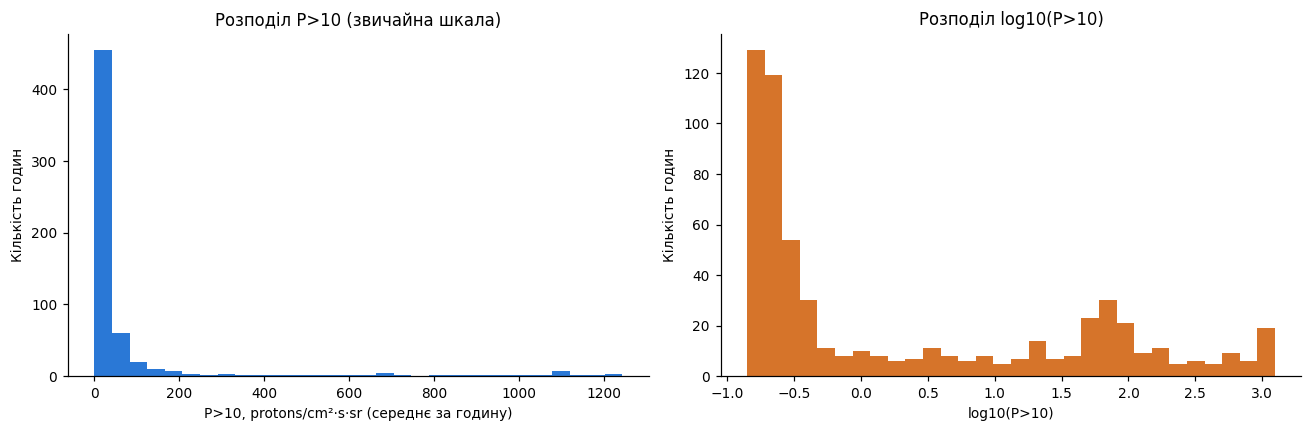

In [19]:
# ВАШ КОД
import numpy as np

потік = M["P >10_mean"]

середнє = потік.mean()
медіана = потік.median()
print("середнє:", середнє)
print("медіана:", медіана)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(потік, bins=30, color="#2a78d6")
axes[0].set_xlabel("P>10, protons/cm²·s·sr (середнє за годину)")
axes[0].set_ylabel("Кількість годин")
axes[0].set_title("Розподіл P>10 (звичайна шкала)")

axes[1].hist(np.log10(потік), bins=30, color="#d6742a")
axes[1].set_xlabel("log10(P>10)")
axes[1].set_ylabel("Кількість годин")
axes[1].set_title("Розподіл log10(P>10)")

plt.tight_layout()
plt.show()

**Висновок:** Розподіл потоку P>10 дуже нерівномірний: переважна більшість годин мають дуже низьке значення потоку – близько 0.1-0.3, тоді як лише кілька десятків годин демонструють екстремально високі сплески, аж до 1243. Медіана правильно відображає типову годину, бо вона просто вказує на середину впорядкованого ряду й не залежить від того, наскільки великими є викиди. А середнє сильно спотворене цими рідкісними, але величезними значеннями – навіть кілька годин із потоком у сотні й тисячі одиниць буквально тягнуть середнє вгору, роблячи його набагато більшим за медіану. Тому медіана в цьому випадку буде набагато чеснішим показником.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

/var/folders/qj/1tz0fkd52c5dy0m076c84h2c0000gn/T/ipykernel_2440/2087247759.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=groups)


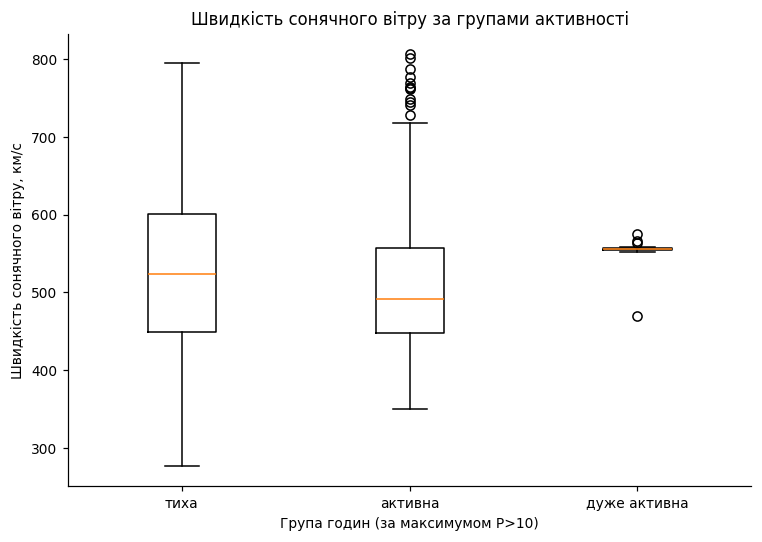

In [20]:
# ВАШ КОД
groups = ["тиха", "активна", "дуже активна"]
data = [M.loc[M["група"] == g, "SPEED"].dropna() for g in groups]

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(data, labels=groups)
ax.set_xlabel("Група годин (за максимумом P>10)")
ax.set_ylabel("Швидкість сонячного вітру, км/с")
ax.set_title("Швидкість сонячного вітру за групами активності")
plt.tight_layout()
plt.show()

**Висновок:** Медіанна швидкість вітру між групами відрізняється несуттєво. Помітна відмінність – не в рівні, а в розкиді: у дуже активній групі значення значно щільніше згруповані, ніж у тихій чи активній. Отже, за цими даними пряма залежність “швидкість вітру -> активність потоку P>10” на рівні медіани не простежується.

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

Коефіцієнт кореляції: -0.06794790187254957


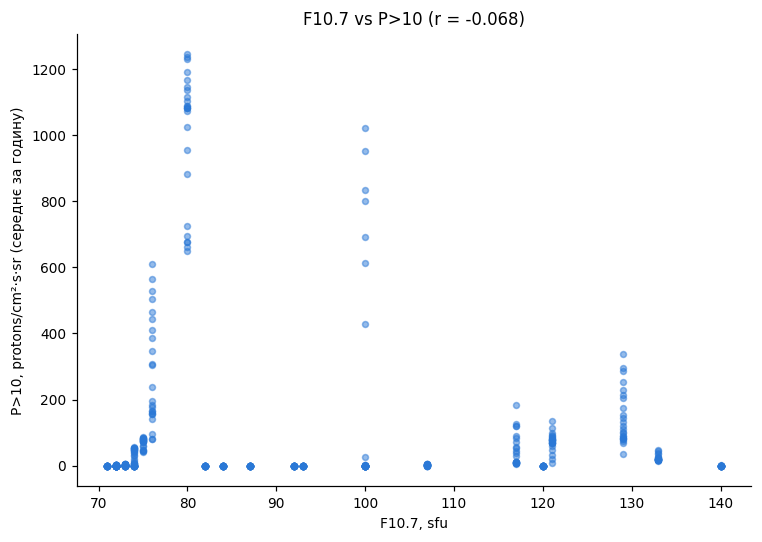

In [21]:
# ВАШ КОД
x = M["F10_7"]
y = M["P >10_mean"]

коефіцієнт = x.corr(y)
print("Коефіцієнт кореляції:", коефіцієнт)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, alpha=0.5, s=15, color="#2a78d6")
ax.set_xlabel("F10.7, sfu")
ax.set_ylabel("P>10, protons/cm²·s·sr (середнє за годину)")
ax.set_title(f"F10.7 vs P>10 (r = {коефіцієнт:.3f})")
plt.tight_layout()
plt.show()

**Висновок:** Кореляція між F10.7 і P>10 дуже слабка і діаграма розсіювання це підтвердила: для одного й того ж значення F10.7 потік P>10 варіюється в діапазоні від майже нуля до понад 1000 одиниць. Це означає, що загальний фоновий рівень сонячної активності не дає змоги передбачити короткочасні спалахи протонного потоку – вочевидь, ці спалахи зумовлені окремими подіями, а не поступовою зміною загального рівня активності Сонця. 

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

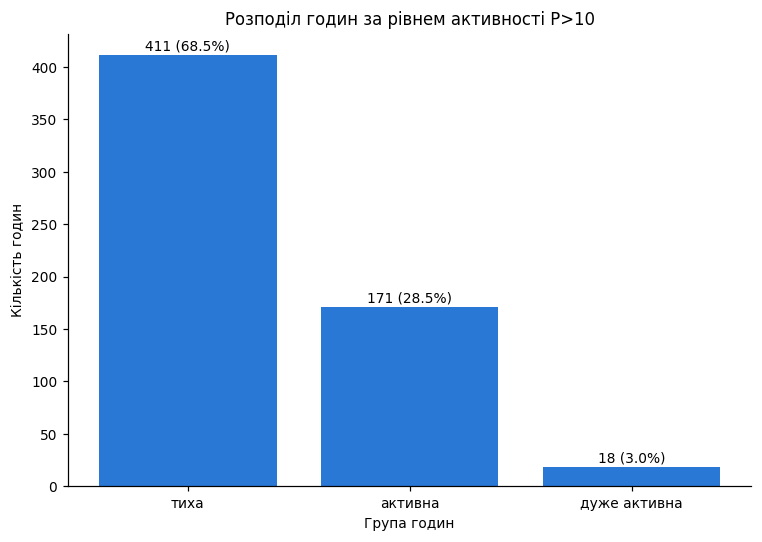

In [22]:
# ВАШ КОД
підрахунок = M["група"].value_counts().reindex(["тиха", "активна", "дуже активна"])
загалом = підрахунок.sum()

fig, ax = plt.subplots(figsize=(7, 5))
стовпчики = ax.bar(підрахунок.index, підрахунок.values, color="#2a78d6")

for стовпчик, кількість in zip(стовпчики, підрахунок.values):
    відсоток = 100 * кількість / загалом
    ax.text(
        стовпчик.get_x() + стовпчик.get_width() / 2,
        кількість + 5,
        f"{кількість} ({відсоток:.1f}%)",
        ha="center",
    )

ax.set_xlabel("Група годин")
ax.set_ylabel("Кількість годин")
ax.set_title("Розподіл годин за рівнем активності P>10")
plt.tight_layout()
plt.show()

**Висновок:** Переважна більшість спостережуваного періоду припадає буквально на тихі години з низьким рівнем протонної активності. Помітно менша частка – активні години, а екстремально високий рівень активності зафіксовано лише у 3% годин, тобто ітенсивні спалахи є рідкісною, короткочасною подією на фоні переважно спокійного періоду.

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

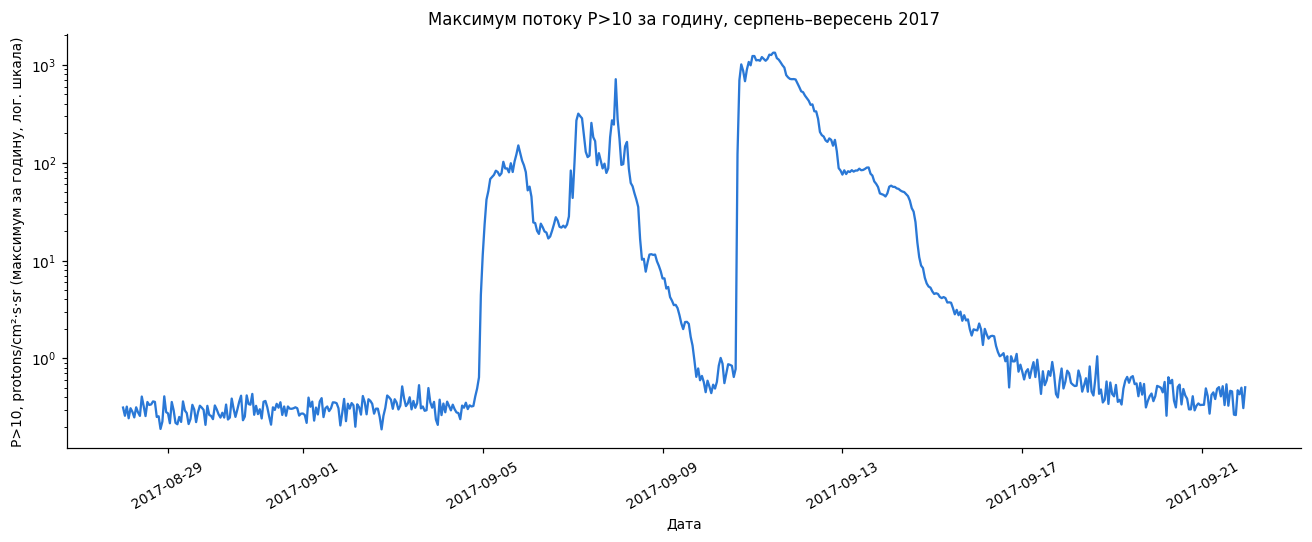

In [23]:
# ВАШ КОД
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(M["ts"], M["P >10_max"], color="#2a78d6")
ax.set_yscale("log")
ax.set_xlabel("Дата")
ax.set_ylabel("P>10, protons/cm²·s·sr (максимум за годину, лог. шкала)")
ax.set_title("Максимум потоку P>10 за годину, серпень–вересень 2017")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Висновок:** Максимум потоку P>10 протягом усього періоду спостереження не розподілений рівномірно: більшу частину часу він тримається на низькому фоновому рівні, але чітко виділяються два періоди підвищеної активності – приблизно 7-8 вересня і значно потужніший, пікове значення понад 1300 protons/cm2*s*sr, приблизно 10-12 вересня. Це узгоджується з висновком графіка 4: переважна більшість годин тихі , а екстремальна активність зосереджена у вузьких, коротких вікнах часу, а не розмазана рівномірно по всьому періоду.

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

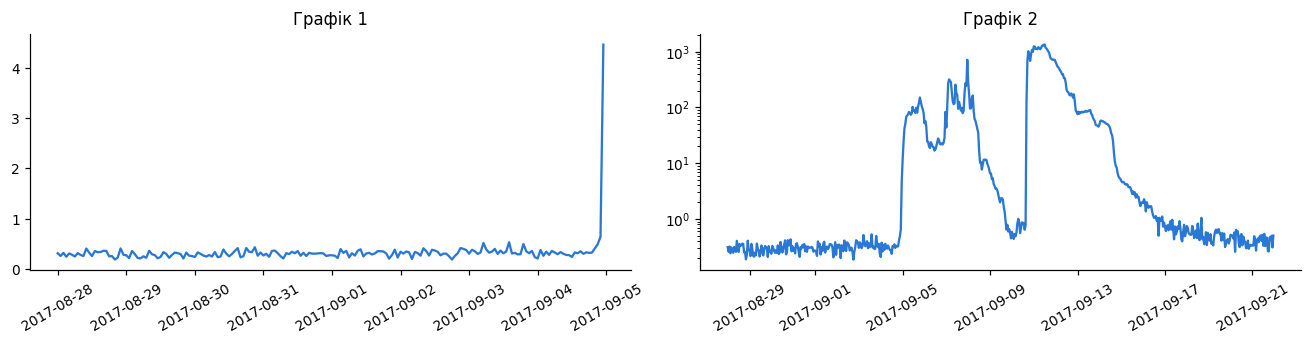

In [24]:
СТОВПЕЦЬ = 'P >10_max'

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: Людина, яка бачила тільки Графік 1, зробить висновок, що місяць був спокійним, майже без активності, бо в обраному вузькому вікні справжніх сплесків просто ще не було.
2. Висновок з другого графіка: Людина, яка бачила тільки Графік 2, побачить весь період і всі сплески, але через логарифмічну шкалу може недооцінити сам масштаб, бо логарифм візуально стискає великі відмінності.
3. Дві відмінності між ними: Діапазон часу – вузьке вікно(28.08-05.09) проти всього періоду(28.08-21.09);
Масштаб осі Y – лінійна проти логарифмічної.



### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

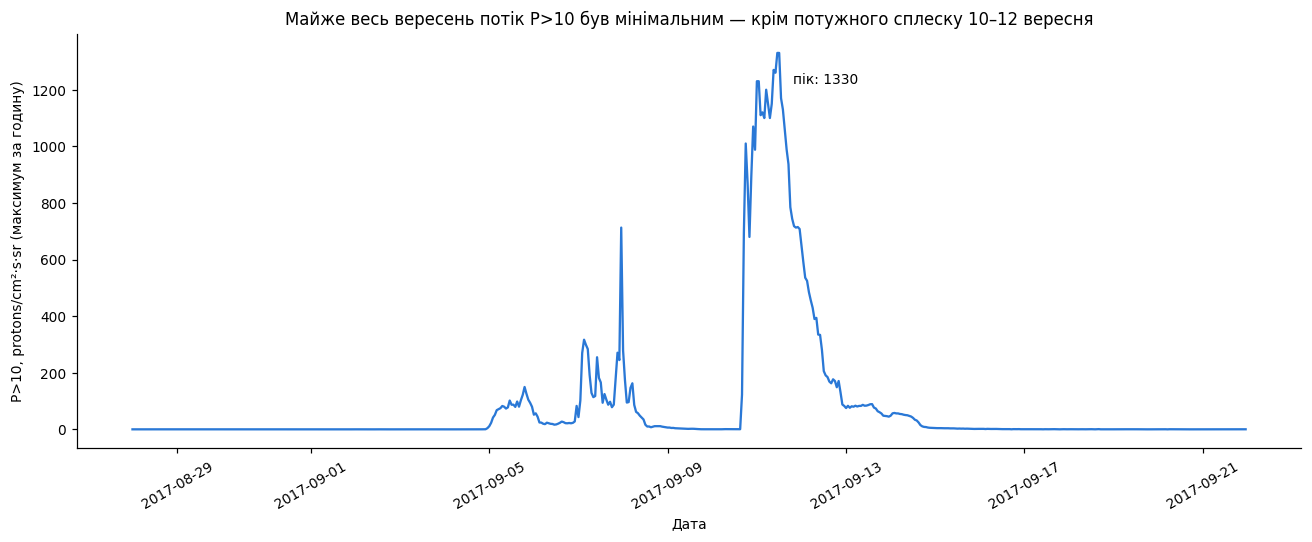

In [25]:
# ВАШ КОД
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(M["ts"], M["P >10_max"], color="#2a78d6")

пік = M["P >10_max"].idxmax()
ax.annotate(
    f"пік: {M.loc[пік, 'P >10_max']:.0f}",
    xy=(M.loc[пік, "ts"], M.loc[пік, "P >10_max"]),
    xytext=(10, -20),
    textcoords="offset points",
)

ax.set_xlabel("Дата")
ax.set_ylabel("P>10, protons/cm²·s·sr (максимум за годину)")
ax.set_title("Майже весь вересень потік P>10 був мінімальним — крім потужного сплеску 10–12 вересня")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Відповідь 6.2:** Було обрано весь період спостережень, щоб не приховати сплеск активності, як це сталось на Графіку 1. Обрала також лінійну шкалу, щоб зберегти чесне відчуття масштабу різниці між фоновим рівнем і піком, яке логарифм з Графіку 2 візуально применшує. Натомість пікове значення підписано прямо на графіку текстом, щоб не втратити цю важливу деталь навіть при лінійній шкалі.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** Розподіл потоку P>10 за годину надзвичайно скошений: середнє(76.45) приблизно у 220 разів більше за медіану(0.34). Це видно на Графіку 1 – на звичайній шкалі майже всі 600 годин втискаються в один стовпчик біля нуля, і лише логарифмічна шкала показує, що насправді розподіл має два горби активності(джерело: Графік 1, Етап 5). 

**Спостереження 2:** Екстремальна активність зосереджена у вузькому вікні часу, а не розмазана по всьому періоду: лише 3% годин(18 з 600) потрапили в групу дуже активної і майже всі вони припадають на 10-12 вересня – саме тоді, коли на Графіку 5 видно найвищий пік потоку(джерело: Графік 4 і Графік 5, Етап 4-5).

**Спостереження 3:** Загальний фоновий рівень сонячної активності практично не повʼязаний із короткочасними сплесками протонного потоку P>10 – коефіцієнт кореляції становить лише -0.068. Діаграма розсіювання показує, що навіть при однаковому F10.7 потік P>10 може коливатись від майже нуля до понад тисячі(джерело: Графік 3, Етап 5).


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [26]:
# ВАШ КОД
active = M["група"] == "активна"

series = (active != active.shift()).cumsum()

lengths = active.groupby(series).sum()

longest = lengths.max()
print("Найдовша серія активних годин поспіль:", longest)

best = lengths.idxmax()
M[series == best][["ts", "P >10_max", "група"]]

Найдовша серія активних годин поспіль: 87


,ts,P >10_max,група
192,2017-09-05 00:00:00,11.4,активна
193,2017-09-05 01:00:00,23.4,активна
194,2017-09-05 02:00:00,41.9,активна
195,2017-09-05 03:00:00,51.3,активна
196,2017-09-05 04:00:00,68.0,активна
...,...,...,...
274,2017-09-08 10:00:00,42.0,активна
275,2017-09-08 11:00:00,35.2,активна
276,2017-09-08 12:00:00,16.6,активна
277,2017-09-08 13:00:00,10.2,активна


**Відповідь 7.2:** Найдовша неперервна серія годин у групі "активна" тривала 87 годин поспіль(майже 3,6 доби) - з 5 вересня 00:00 до 8 вересня 14:00 2017 року. Це показує, що підвищена активність потоку P>10 могла триматись безперервно кілька діб поспіль, а не лише спалахувати на короткі години.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [27]:
ІНСТРУМЕНТИ_ШІ = 'Gemini'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'синтаксис',
    'етап 3, паспорт даних і дивні значення':     'синтаксис',
    'етап 4, об’єднання таблиць':                 'синтаксис',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'код, перевірено',
    'етапи 6–7, порівняння графіків і спостереження': 'ні',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = (
    'ШІ використовувався як консультант для пояснення логіки методів '
    'resample та merge, а також для перевірки синтаксису побудови графіків і '
    'форматування висновків.'
)

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [28]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Смачило Іванна Ростиславівна
інструменти:                                   Gemini
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    синтаксис
етап 3, паспорт даних і дивні значення:        синтаксис
етап 4, об’єднання таблиць:                    синтаксис
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                код, перевірено
етапи 6–7, порівняння графіків і спостереження: ні
------------------------------------------------------------------------------
перевірено автором:
ШІ використовувався як консультант для пояснення логіки методів resample та merge, а також для перевірки синтаксису побудови графіків і форматування висновків.
Автор підтверджує, що може пояснити кожен рядок коду під час захисту.


---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [29]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (600, 21)


In [30]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
